## **Gradient Descent Only on b and m is constant**

In [1]:
from sklearn.datasets import make_regression
import numpy as np
# rcParams

In [50]:
x,y = make_regression(n_samples=4 , n_features=1 , n_informative=1 , n_targets=1 , noise=80 , random_state=13)

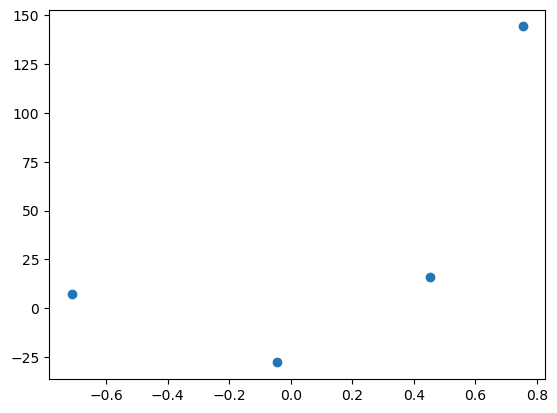

In [51]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [52]:
# Lets apply OLS
from sklearn.linear_model import LinearRegression

In [53]:
reg = LinearRegression()
reg.fit(x,y)

LinearRegression()

In [54]:
reg.coef_ , reg.intercept_

(array([78.35063668]), np.float64(26.15963284313262))

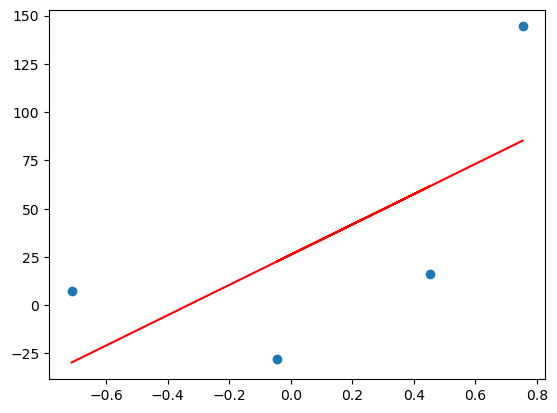

In [55]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red')

#### **Applying Gradient Descent**

In [56]:
# Lets apply gradient descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * x)+0).reshape(4)
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

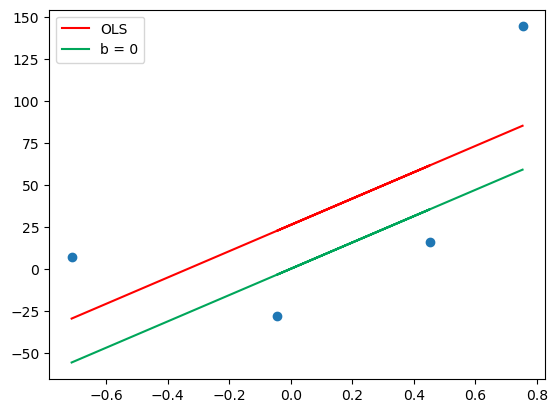

In [57]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red' , label="OLS")
plt.plot(x,y_pred,color='#00a65a' , label="b = 0")
plt.legend()
plt.show()

In [58]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [59]:
# Let's take learning rate = 0.1
lr = 0.1
step_size = lr*loss_slope
step_size

np.float64(-20.927763408209216)

In [60]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

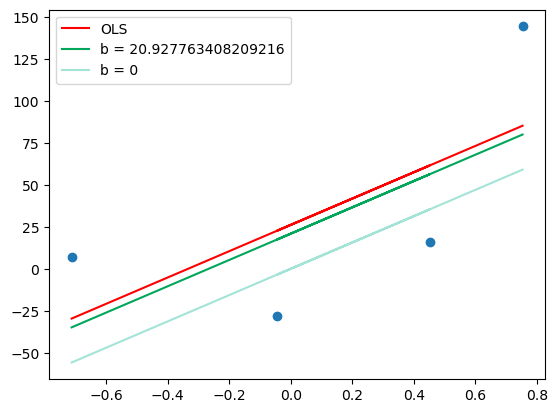

In [61]:
y_pred1 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red' , label="OLS")
plt.plot(x,y_pred1,color='#00a65a' , label="b = {}".format(b))
plt.plot(x,y_pred,color='#A3E4D7' , label="b = 0")
plt.legend()
plt.show()

In [62]:
# Iteration 2 
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [63]:
step_size = lr * loss_slope
step_size

np.float64(-4.185552681641844)

In [64]:
b0 = b
b = b - step_size
b

np.float64(25.11331608985106)

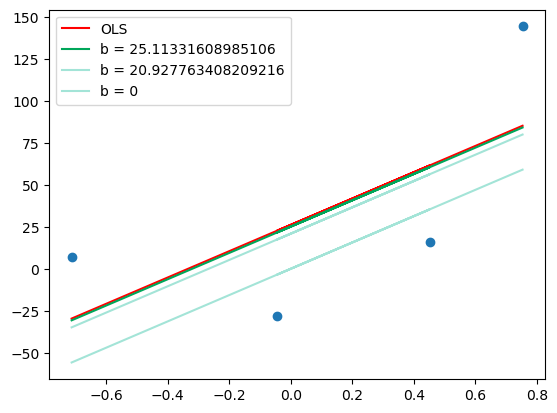

In [65]:
y_pred2 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red' , label="OLS")
plt.plot(x,y_pred2,color='#00a65a' , label="b = {}".format(b))
plt.plot(x,y_pred1,color='#A3E4D7' , label="b = {}".format(b0))
plt.plot(x,y_pred,color='#A3E4D7' , label="b = 0")
plt.legend()
plt.show()

In [66]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*x.ravel() - b)
loss_slope

np.float64(-8.371105363283675)

In [67]:
step_size = lr * loss_slope
step_size

np.float64(-0.8371105363283675)

In [68]:
# b0 = b
b1 = b
b = b - step_size
b

np.float64(25.95042662617943)

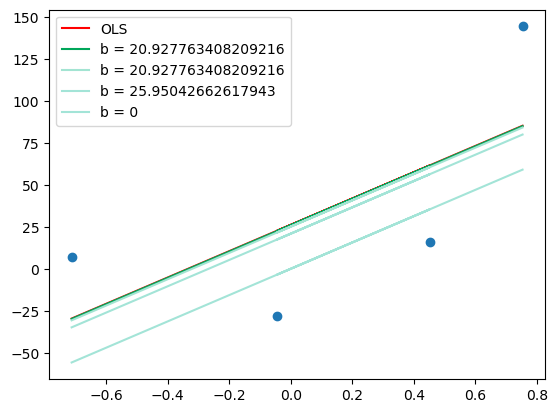

In [69]:
y_pred3 = ((78.35 * x)+b).reshape(4)

plt.scatter(x,y)
plt.plot(x,reg.predict(x),color='red' , label="OLS")
plt.plot(x,y_pred3,color='#00a65a' , label="b = {}".format(b0))
plt.plot(x,y_pred2,color='#A3E4D2' , label="b = {}".format(b0))
plt.plot(x,y_pred1,color='#A3E4D7' , label="b = {}".format(b))
plt.plot(x,y_pred,color='#A3E4D7' , label="b = 0")
plt.legend()
plt.show()

#### **Summarizing all code into iterations**

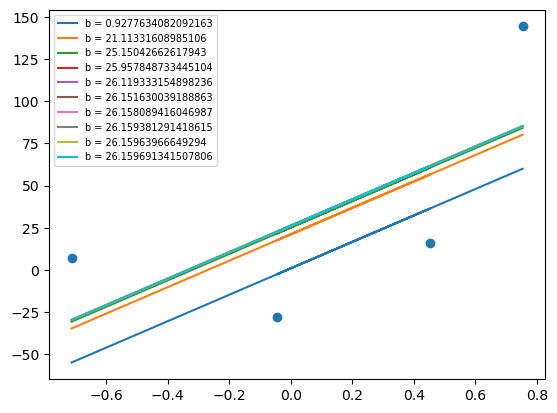

In [88]:
b = -100
m = 78.35
lr = 0.1
epochs = 10

for i in range(epochs):
    
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    step_size = lr * loss_slope
    
    # print(b,step_size)
    
    b = b - step_size

    y_pred = m * x + b
    
    plt.plot(x,y_pred, label=f'b = {b}')

plt.scatter(x,y)
plt.legend(prop={'size':7})
plt.show()

### **Making our own class**

In [89]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [90]:
x, y = make_regression(n_samples=100 , n_features=1 , n_informative=1 , n_targets=1 , noise=20)

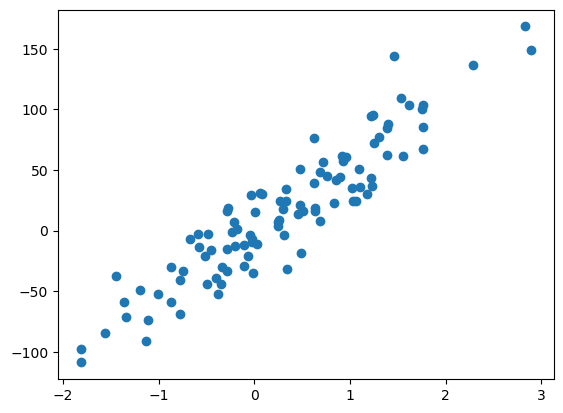

In [91]:
plt.scatter(x,y)

In [92]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [93]:
reg.fit(x,y)
print(reg.coef_)
print(reg.intercept_)

[53.28923191]
-0.07000548931909911


In [154]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
        self.m = 53.29
        self.b = -120
        self.epochs = epochs
        self.lr = learning_rate

    def fit(self,x,y):
        # print('Initial b : ',self.b)
        # Calculate the b using GD
        for i in range(self.epochs):
            
            loss_slope = -2 * np.sum(y - self.m*x.ravel() - self.b)
            self.b = self.b - (self.lr*loss_slope)
            
            # print(loss_slope,self.b)
            
        print(self.b)

In [155]:
gdr = GDRegressor(0.003,50)

In [156]:
gdr.fit(x,y)

-120
-0.07023506855117359
